# Cross-dataset distributions

Same per-cell distributions as `2_distributions_*_lite.ipynb`, but rendered as violin
plots with one violin per production dataset on a shared axis. Categorical breakdowns
(guides-assigned binning, NTC split) become grouped bar charts.

Loads only the obs DataFrames, guide var, guide_assignment sparse layer, and HTO X (Hon
CM only) via `anndata.io.read_elem` — no `X` for gene/guide, no `uns/{cis,trans}_per_*`.
Per-dataset RAM is ~50–150 MB; total for all four datasets is well under 1 GB.

In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import h5py
try:
    from anndata.io import read_elem
except ImportError:  # anndata < 0.11
    from anndata.experimental import read_elem

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
# Paths, palette, output dir
PROJECT_ROOT = Path("/cellar/users/aklie/projects/tf_perturb_seq")
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("production_TF-Perturb-seq", "dataset_colors")
dataset_order  = load_colors("production_TF-Perturb-seq", "dataset_order")

BASE_DIR = PROJECT_ROOT / "docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc"
MANIFEST = BASE_DIR / "manifests/manifest.tsv"
OUTPUT_DIR = BASE_DIR / "results/cross_dataset_distributions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

paths_df = pd.read_csv(MANIFEST, sep="\t")
paths_df = paths_df[paths_df['dataset'].isin(dataset_order)].copy()
paths_df['dataset'] = pd.Categorical(paths_df['dataset'], categories=dataset_order, ordered=True)
paths_df = paths_df.sort_values('dataset').reset_index(drop=True)

present_datasets    = list(paths_df['dataset'])
present_short_names = list(paths_df['short_name'])
short_by_full       = dict(zip(paths_df['dataset'], paths_df['short_name']))
color_by_short      = {short_by_full[ds]: dataset_colors[ds] for ds in present_datasets}
sn_palette          = [color_by_short[sn] for sn in present_short_names]

print(f"Output: {OUTPUT_DIR}")
paths_df[['dataset', 'short_name']]

## Lightweight per-dataset loader

In [10]:
def load_dataset_aggregates(row):
    """Return per-cell DataFrame + per-guide DataFrame + per-target DataFrame for one row.

    Memory: ~100 MB for the largest dataset. We discard the guide_assignment matrix
    after extracting the three counts we need (total / NTC / non-NTC per cell).
    """
    mudata_path = Path(row['mudata'])
    pgc_path    = Path(row['qc_dir']) / row['per_guide_capture']
    short_name  = row['short_name']

    with h5py.File(mudata_path, "r") as h5:
        modalities = list(h5['mod'].keys())
        has_hto = 'hashing' in modalities

        gene_obs  = read_elem(h5['mod/gene/obs'])
        guide_obs = read_elem(h5['mod/guide/obs'])
        guide_var = read_elem(h5['mod/guide/var'])
        ga        = read_elem(h5['mod/guide/layers/guide_assignment'])
        if not sp.issparse(ga):
            ga = sp.csr_matrix(ga)

        # Identify NTC guides
        type_col = 'type' if 'type' in guide_var.columns else 'label'
        is_ntc = guide_var[type_col].astype(str).str.contains(
            'non.targeting|non_targeting', regex=True, case=False).values

        n_assigned   = np.asarray(ga.sum(axis=1)).ravel()
        ga_csc       = ga.tocsc()
        ntc_counts   = np.asarray(ga_csc[:, is_ntc].sum(axis=1)).ravel()
        nontc_counts = np.asarray(ga_csc[:, ~is_ntc].sum(axis=1)).ravel()

        if has_hto:
            hto_X = read_elem(h5['mod/hashing/X'])
            hto_umi = np.asarray(hto_X.sum(axis=1)).ravel()
        else:
            hto_umi = None

    per_cell = pd.DataFrame({
        'short_name': short_name,
        'gene_umi':           gene_obs['n_counts'].astype(float).values,
        'pct_mito':           gene_obs['percent_mito'].astype(float).values,
        'n_genes':            np.expm1(gene_obs['log1p_n_genes_by_counts'].astype(float).values),
        'guide_umi':          guide_obs['total_guide_umis'].astype(float).values,
        'n_expressed_guides': guide_obs['num_expressed_guides'].astype(int).values,
        'n_assigned_guides':  n_assigned.astype(int),
        'n_assigned_ntc':     ntc_counts.astype(int),
        'n_assigned_nontc':   nontc_counts.astype(int),
        'hto_umi':            hto_umi if has_hto else np.nan,
    })

    # per_guide_capture — canonicalize label, then aggregate to per-target.
    # Some datasets (Huangfu DE/ESC) ship per_guide_capture.tsv without a 'label'
    # column; fall back to guide_var (mod/guide/var/type) by joining on guide_id.
    pgc = pd.read_csv(pgc_path, sep='\t')
    pgc['short_name'] = short_name
    if 'label' not in pgc.columns:
        # guide_var has 'guide_id' as both an index level and a column (same values,
        # different roles after read_elem). Strip the index to avoid merge ambiguity.
        type_col = 'type' if 'type' in guide_var.columns else 'label'
        guide_ids = guide_var['guide_id'].values if 'guide_id' in guide_var.columns else guide_var.index.values
        label_lookup = pd.DataFrame({
            'guide_id': guide_ids,
            'label':    guide_var[type_col].values,
        })
        pgc = pgc.merge(label_lookup, on='guide_id', how='left')
    pgc['label_canonical'] = (
        pgc['label'].astype(str)
        .str.strip().str.replace('-', '_').str.replace(' ', '_').str.lower()
        .replace({'targeting': 'tf_targeting'})
    )

    per_target = (
        pgc.groupby(['short_name', 'gene_name'], dropna=False)
           .agg(n_cells_assigned=('n_cells_assigned', 'sum'),
                n_guides=('guide_id', 'count'),
                label_canonical=('label_canonical', lambda s: s.mode().iat[0] if len(s) else 'unknown'))
           .reset_index()
    )

    return per_cell, pgc, per_target


PER_CELL_FRAMES   = []
PER_GUIDE_FRAMES  = []
PER_TARGET_FRAMES = []

for _, row in paths_df.iterrows():
    print(f"Loading {row['short_name']} ...", flush=True)
    pc, pg, pt = load_dataset_aggregates(row)
    PER_CELL_FRAMES.append(pc)
    PER_GUIDE_FRAMES.append(pg)
    PER_TARGET_FRAMES.append(pt)

per_cell   = pd.concat(PER_CELL_FRAMES,   ignore_index=True)
per_guide  = pd.concat(PER_GUIDE_FRAMES,  ignore_index=True)
per_target = pd.concat(PER_TARGET_FRAMES, ignore_index=True)

per_cell['short_name']   = pd.Categorical(per_cell['short_name'],   categories=present_short_names, ordered=True)
per_guide['short_name']  = pd.Categorical(per_guide['short_name'],  categories=present_short_names, ordered=True)
per_target['short_name'] = pd.Categorical(per_target['short_name'], categories=present_short_names, ordered=True)

print()
print("per_cell shape:  ", per_cell.shape)
print("per_guide shape: ", per_guide.shape)
print("per_target shape:", per_target.shape)
per_cell.groupby('short_name', observed=True).size()

Loading Hon CM ...
Loading Huangfu DE ...
Loading Huangfu ESC ...
Loading Gersbach Hep ...

per_cell shape:   (2517001, 10)
per_guide shape:  (56604, 15)
per_target shape: (8252, 5)


short_name
Hon CM          1004091
Huangfu DE       269491
Huangfu ESC      189599
Gersbach Hep    1053820
dtype: int64

## UMI per cell — gene, guide, (HTO where present)

Violins on log10 scale, one per dataset. HTO panel shows only datasets where the
modality exists (currently Hon CM only).

/tmp/ipykernel_4061778/3276738924.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y=col, ax=ax,
/tmp/ipykernel_4061778/3276738924.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y=col, ax=ax,
/tmp/ipykernel_4061778/3276738924.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y=col, ax=ax,


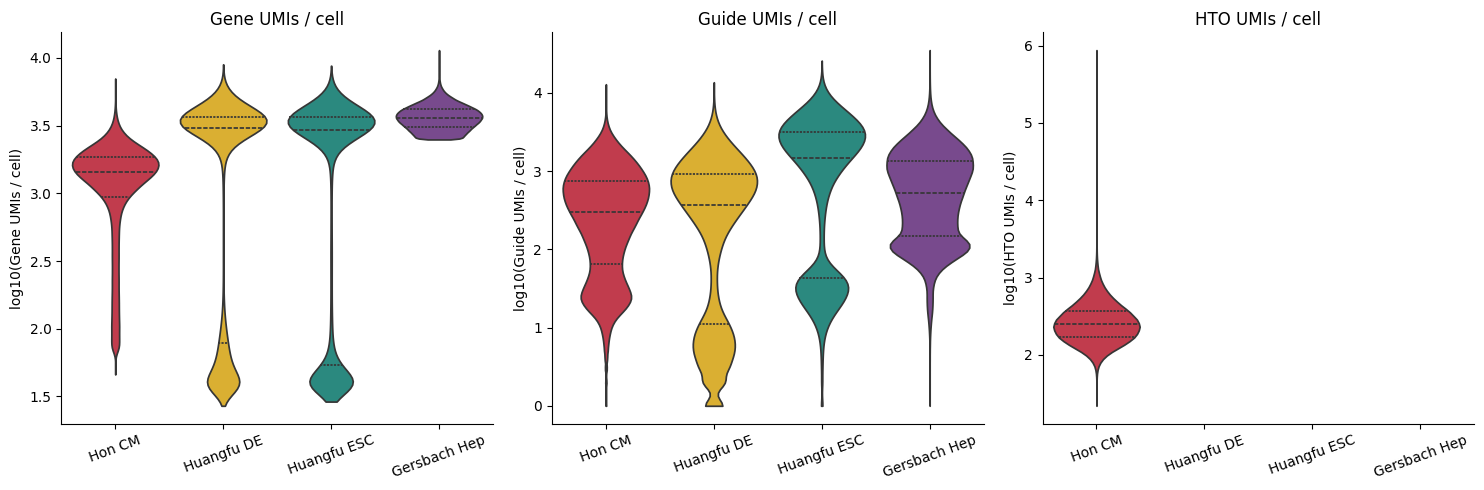

In [11]:
panels = [
    ('gene_umi',  'Gene UMIs / cell'),
    ('guide_umi', 'Guide UMIs / cell'),
]
# HTO only where any dataset has it
hto_mask = per_cell['hto_umi'].notna()
if hto_mask.any():
    panels.append(('hto_umi',  'HTO UMIs / cell'))

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
if len(panels) == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, panels):
    df = per_cell[['short_name', col]].dropna()
    df = df[df[col] > 0].copy()
    df[col] = np.log10(df[col])
    sns.violinplot(data=df, x='short_name', y=col, ax=ax,
                   order=present_short_names, palette=sn_palette,
                   inner='quartile', cut=0)
    ax.set_xlabel('')
    ax.set_ylabel(f'log10({title})')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"umi_per_cell_violins.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Gene quality — genes / cell and % mito

/tmp/ipykernel_4061778/2360058807.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=per_cell, x='short_name', y=col, ax=ax,
/tmp/ipykernel_4061778/2360058807.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=per_cell, x='short_name', y=col, ax=ax,


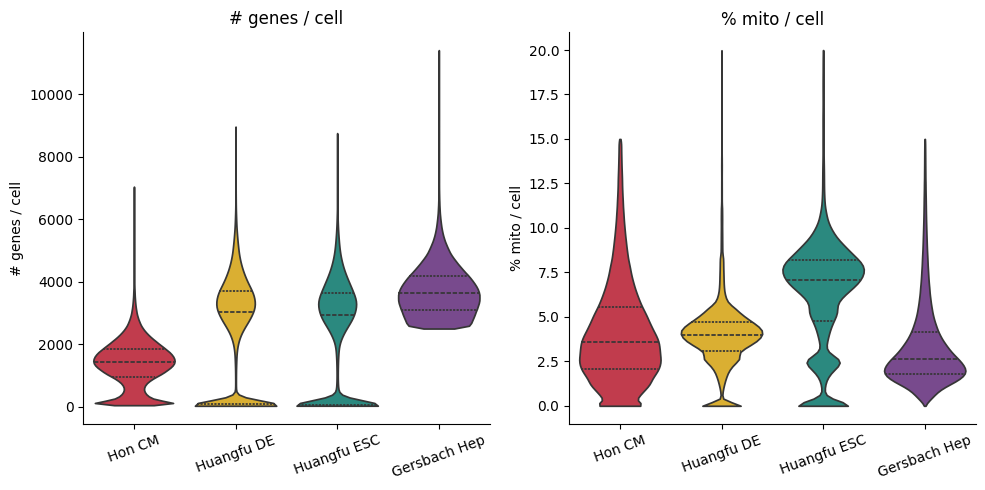

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (col, title) in zip(axes, [('n_genes', '# genes / cell'),
                                    ('pct_mito', '% mito / cell')]):
    sns.violinplot(data=per_cell, x='short_name', y=col, ax=ax,
                   order=present_short_names, palette=sn_palette,
                   inner='quartile', cut=0)
    ax.set_xlabel('')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"gene_quality_violins.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Guides assigned per cell

Left: violin of `n_assigned_guides` (clipped at p99.5 per dataset for readability).
Right: grouped bar of the same metric binned into `0 / 1 / 2 / 3 / 4 / 5+`.

/tmp/ipykernel_4061778/172588577.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=clipped, x='short_name', y='n_assigned_guides', ax=ax,


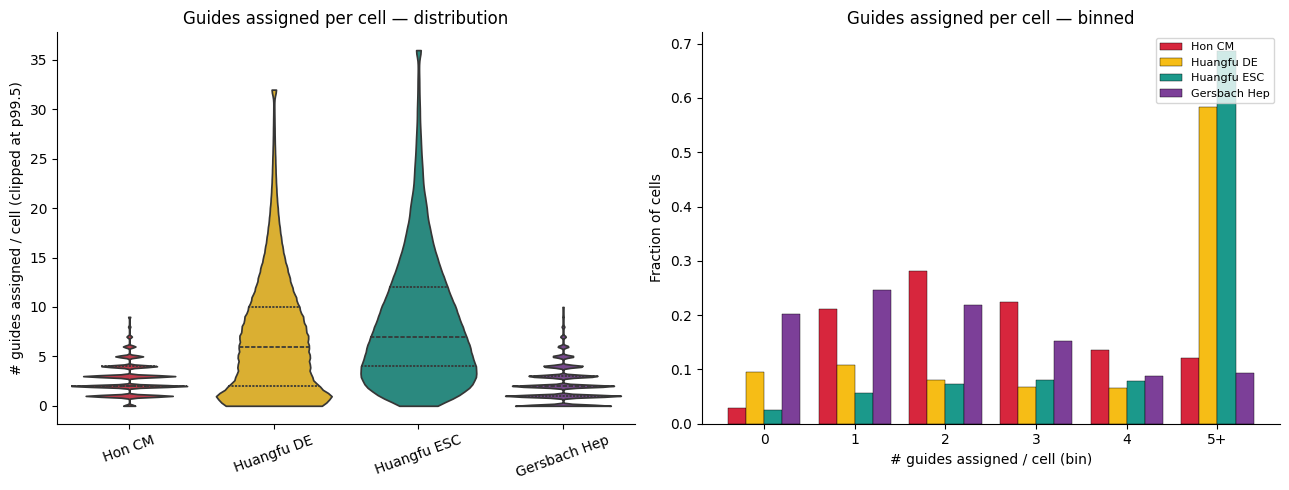

bin,0,1,2,3,4,5+
short_name,,,,,,
Hon CM,0.0289,0.2114,0.2810,0.2235,0.1348,0.1204
Huangfu DE,0.0947,0.1082,0.0810,0.0679,0.0656,0.5826
Huangfu ESC,0.0253,0.0556,0.0736,0.0798,0.0791,0.6867
Gersbach Hep,0.2021,0.2457,0.2192,0.1513,0.0885,0.0932


In [13]:
# Clip per-dataset for the violin
clipped = per_cell[['short_name', 'n_assigned_guides']].copy()
caps = clipped.groupby('short_name', observed=True)['n_assigned_guides'].quantile(0.995)
clipped['n_assigned_guides'] = clipped.apply(
    lambda r: min(r['n_assigned_guides'], caps[r['short_name']] + 1), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sns.violinplot(data=clipped, x='short_name', y='n_assigned_guides', ax=ax,
               order=present_short_names, palette=sn_palette,
               inner='quartile', cut=0)
ax.set_xlabel('')
ax.set_ylabel('# guides assigned / cell (clipped at p99.5)')
ax.set_title('Guides assigned per cell — distribution')
ax.tick_params(axis='x', rotation=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Binned grouped bar
ax = axes[1]
bin_labels = ['0', '1', '2', '3', '4', '5+']
binned = pd.cut(
    per_cell['n_assigned_guides'].values,
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, np.inf],
    labels=bin_labels,
)
binned_df = pd.DataFrame({'short_name': per_cell['short_name'].values, 'bin': binned})
counts = binned_df.groupby(['short_name', 'bin'], observed=True).size().unstack(fill_value=0)
counts = counts.reindex(index=present_short_names, columns=bin_labels)
fracs = counts.div(counts.sum(axis=1), axis=0)

n_bins = len(bin_labels)
width = 0.8 / len(present_short_names)
x = np.arange(n_bins)
for i, sn in enumerate(present_short_names):
    ax.bar(x + (i - (len(present_short_names) - 1) / 2) * width,
           fracs.loc[sn].values, width=width,
           color=color_by_short[sn], edgecolor='black', linewidth=0.3, label=sn)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.set_xlabel('# guides assigned / cell (bin)')
ax.set_ylabel('Fraction of cells')
ax.set_title('Guides assigned per cell — binned')
ax.legend(fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"guides_per_cell_violin_and_bins.{ext}", dpi=300, bbox_inches='tight')
plt.show()

counts.to_csv(OUTPUT_DIR / 'guides_per_cell_bins.tsv', sep='\t')
fracs.round(4)

## NTC vs targeting category breakdown

For each cell, split assignments into NTC vs non-NTC guides, then assign one of five
categories: `no assignment / exactly 1 / NTC-only (≥2) / targeting-only (≥2) / mixed`.

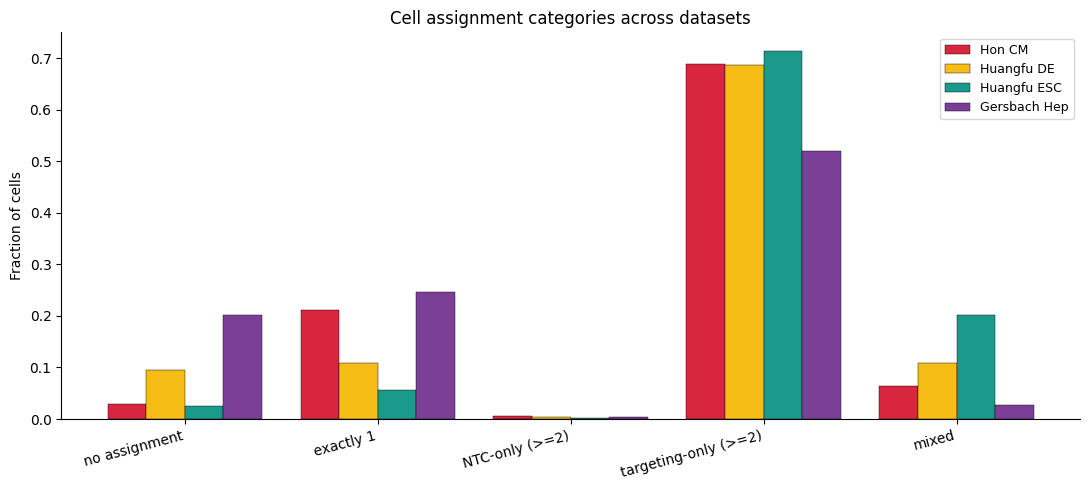

cat,no assignment,exactly 1,NTC-only (>=2),targeting-only (>=2),mixed
short_name,,,,,
Hon CM,0.0289,0.2114,0.0054,0.6894,0.0649
Huangfu DE,0.0947,0.1082,0.0030,0.6862,0.1079
Huangfu ESC,0.0253,0.0556,0.0027,0.7143,0.2021
Gersbach Hep,0.2021,0.2457,0.0041,0.5207,0.0274


In [14]:
def categorize(row):
    total = row['n_assigned_guides']
    ntc   = row['n_assigned_ntc']
    nontc = row['n_assigned_nontc']
    if total == 0:
        return 'no assignment'
    if total == 1:
        return 'exactly 1'
    if nontc == 0:
        return 'NTC-only (>=2)'
    if ntc == 0:
        return 'targeting-only (>=2)'
    return 'mixed'

cats = per_cell.apply(categorize, axis=1)
cat_order = ['no assignment', 'exactly 1', 'NTC-only (>=2)', 'targeting-only (>=2)', 'mixed']

cat_df = pd.DataFrame({'short_name': per_cell['short_name'].values, 'cat': cats.values})
cat_counts = cat_df.groupby(['short_name', 'cat'], observed=True).size().unstack(fill_value=0)
cat_counts = cat_counts.reindex(index=present_short_names, columns=cat_order)
cat_fracs  = cat_counts.div(cat_counts.sum(axis=1), axis=0)


def _plot_categories(values, ylabel, title, fname, log=False):
    fig, ax = plt.subplots(figsize=(11, 5))
    n_cats = len(cat_order)
    width = 0.8 / len(present_short_names)
    x = np.arange(n_cats)
    for i, sn in enumerate(present_short_names):
        ax.bar(x + (i - (len(present_short_names) - 1) / 2) * width,
               values.loc[sn].values, width=width,
               color=color_by_short[sn], edgecolor='black', linewidth=0.3, label=sn)
    ax.set_xticks(x)
    ax.set_xticklabels(cat_order, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if log:
        ax.set_yscale('log')
    plt.tight_layout()
    for ext in ("pdf", "png"):
        plt.savefig(OUTPUT_DIR / f"{fname}.{ext}", dpi=300, bbox_inches='tight')
    plt.show()


_plot_categories(cat_fracs, 'Fraction of cells',
                 'Cell assignment categories across datasets (fraction)',
                 'cell_category_breakdown')
_plot_categories(cat_counts, 'Number of cells',
                 'Cell assignment categories across datasets (count)',
                 'cell_category_breakdown_counts', log=True)

cat_fracs.round(4).to_csv(OUTPUT_DIR / 'cell_category_breakdown.tsv', sep='\t')
cat_counts.to_csv(OUTPUT_DIR / 'cell_category_breakdown_counts.tsv', sep='\t')
cat_fracs.round(4)


## Cells per guide, by label

One subplot per guide label (positive control / negative control / non-targeting /
tf_targeting). Datasets on the x-axis, cells/guide on the y-axis.

/tmp/ipykernel_4061778/3852900978.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
/tmp/ipykernel_4061778/3852900978.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
/tmp/ipykernel_4061778/3852900978.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
/tmp/ipykernel_4061778/3852900978.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

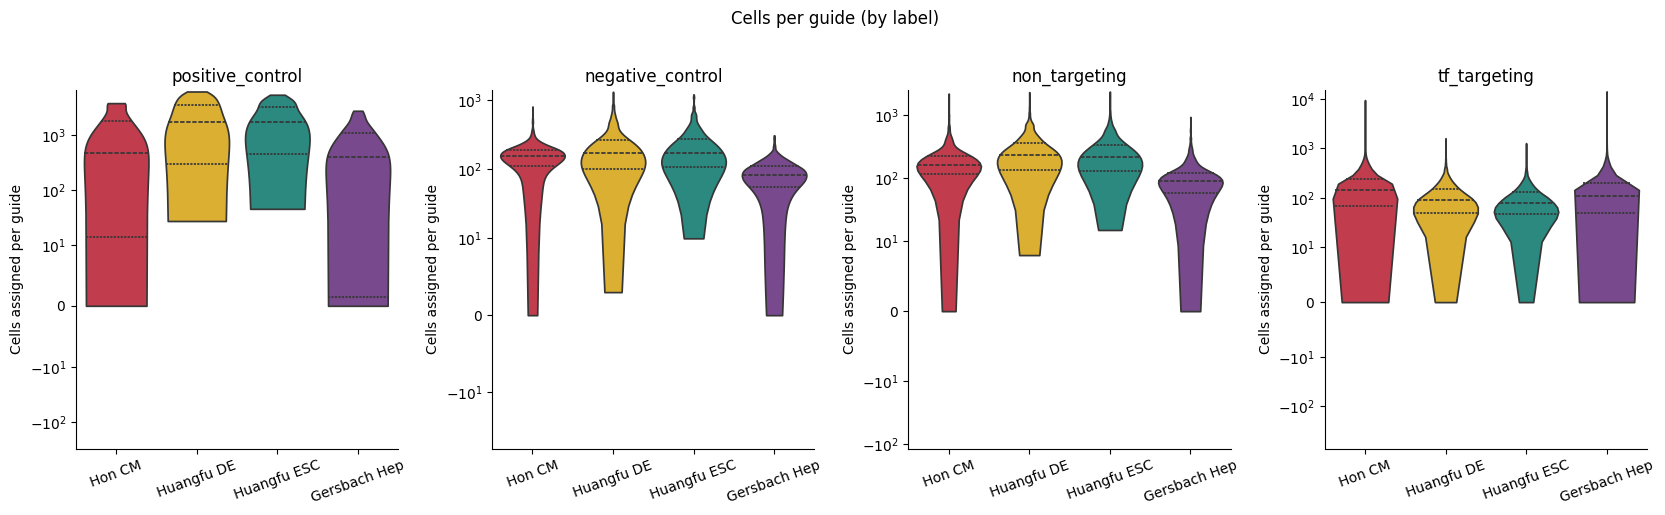

In [15]:
LABEL_ORDER = ['positive_control', 'negative_control', 'non_targeting', 'tf_targeting']
labels_present = [c for c in LABEL_ORDER if c in per_guide['label_canonical'].unique()]

fig, axes = plt.subplots(1, len(labels_present), figsize=(4.2 * len(labels_present), 5),
                         sharey=False)
if len(labels_present) == 1:
    axes = [axes]

for ax, lab in zip(axes, labels_present):
    df = per_guide[per_guide['label_canonical'] == lab]
    sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
                   order=present_short_names, palette=sn_palette,
                   inner='quartile', cut=0)
    ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel('')
    ax.set_ylabel('Cells assigned per guide')
    ax.set_title(lab)
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Cells per guide (by label)', y=1.02)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"cells_per_guide_by_label_violins.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Cells per target, by label

Same as above but summed across all guides for each `gene_name`.

/tmp/ipykernel_4061778/4044022238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
/tmp/ipykernel_4061778/4044022238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
/tmp/ipykernel_4061778/4044022238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
/tmp/ipykernel_4061778/4044022238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

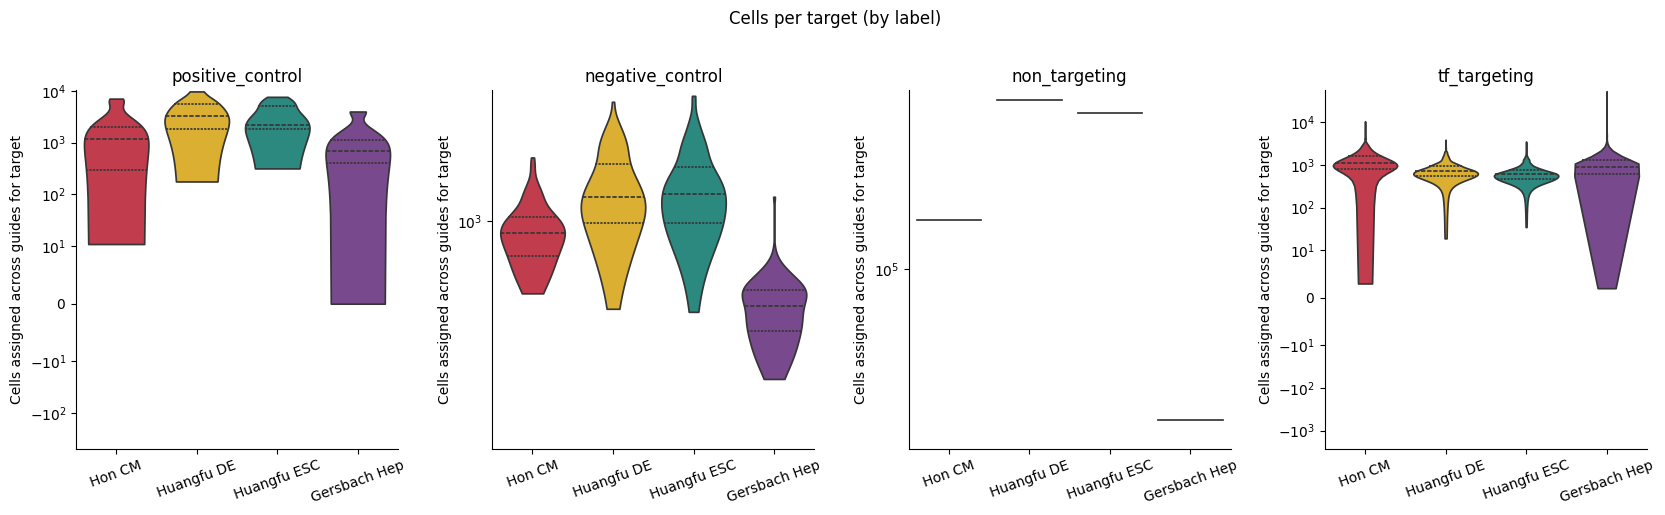

In [16]:
targets_labels_present = [c for c in LABEL_ORDER if c in per_target['label_canonical'].unique()]

fig, axes = plt.subplots(1, len(targets_labels_present), figsize=(4.2 * len(targets_labels_present), 5),
                         sharey=False)
if len(targets_labels_present) == 1:
    axes = [axes]

for ax, lab in zip(axes, targets_labels_present):
    df = per_target[per_target['label_canonical'] == lab]
    sns.violinplot(data=df, x='short_name', y='n_cells_assigned', ax=ax,
                   order=present_short_names, palette=sn_palette,
                   inner='quartile', cut=0)
    ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel('')
    ax.set_ylabel('Cells assigned across guides for target')
    ax.set_title(lab)
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Cells per target (by label)', y=1.02)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"cells_per_target_by_label_violins.{ext}", dpi=300, bbox_inches='tight')
plt.show()

per_target.to_csv(OUTPUT_DIR / 'cells_per_target.tsv', sep='\t', index=False)

---
# DONE!